# MNIST-Add-Cov: looking at the inputs

`features` is a `[num_covariates, 28, 28]` tensor, one digit image per channel
(channel stacking, matching `data.num_covariates` and `IntCEMMNISTEncoder`).

`experiment` (from `configs/data/mnist_add.yaml`) selects the concept/hidden-concept
layout below -- `concept_names` / `oracle_names` are read off the same experiment, so
this notebook follows whatever the yaml is currently set to.

In [5]:
import matplotlib.pyplot as plt
import torch
from omegaconf import OmegaConf

from datasets.MNIST_add_cov_dataset import (
    get_MNIST_add_cov_datasets,
    get_mnist_add_cov_concept_names,
    get_mnist_add_cov_oracle_names,
)

# The run config, read straight off the yaml so the notebook sees the same
# split sizes / planted function / corruption as training does.
config_data = OmegaConf.merge(
    OmegaConf.load("configs/data/data_defaults.yaml"),
    OmegaConf.load("configs/data/mnist_add.yaml"),
)
config_data.data_path = "datasets/"   # local path; the cluster uses work/Data/
print(OmegaConf.to_yaml(config_data))

data_path: datasets/
incomplete_dir: incomplete_data/
defaults:
- data_defaults
dataset: MNIST-Add-Cov
experiment: hidden_carry
num_classes: 8
num_concepts: 4
num_residuals: 1
num_covariates: 4
train_dataset_size: 12000
val_dataset_size: 2400
test_dataset_size: 10000
val_percent: 0.2
data_seed: null
save_data: false
save_data_name: null
data_dir_name: null
removed_concepts: []
planted_function: xor
corruption: gaussian
corruption_strength: 0.5
corruption_probability: 1.0
corruption_channels: null
test_corruption: gaussian
test_corruption_strength: 0.5
test_corruption_probability: 1.0
save_predicted_concepts_residuals: true
save_residual_channel: true
save_concept_and_residual_channel: true



In [6]:
trainset, valset, testset = get_MNIST_add_cov_datasets(config_data, seed=0)
concept_names = get_mnist_add_cov_concept_names(config_data.experiment)
oracle_names = get_mnist_add_cov_oracle_names(config_data.experiment)
print(len(trainset), len(valset), len(testset))
print(concept_names, "| oracle:", oracle_names)

MNIST-Add-Cov split fingerprints (data seed=0, experiment=hidden_carry, planted_function=xor):
  train n=12000  sha256[:16]=032c286bb1f1e387
  val   n=2400   sha256[:16]=dcd2b6348798764a
  test  n=10000  sha256[:16]=be3c30b27cac8be3
  concepts exposed: ['A::digit1_ge_5', 'B::digit2_ge_5', 'D1::digit3_ge_5', 'D2::digit4_ge_5']
  Matching fingerprints => identical train/val/test samples across machines (independent of which concepts are exposed).
12000 2400 10000
['A::digit1_ge_5', 'B::digit2_ge_5', 'D1::digit3_ge_5', 'D2::digit4_ge_5'] | oracle: ['A2::digit2_is_odd', 'X::carry_d1_plus_d2_ge_10']


In [7]:
print(type(trainset), type(valset), type(testset))
print(trainset[0])

<class 'datasets.MNIST_add_cov_dataset.MNISTAddCovDataset'> <class 'datasets.MNIST_add_cov_dataset.MNISTAddCovDataset'> <class 'datasets.MNIST_add_cov_dataset.MNISTAddCovDataset'>
{'img_code': 0, 'labels': tensor(7), 'features': tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.6205, 0.0000, 0.0000],
         [0.1932, 0.0000, 0.0666,  ..., 0.7563, 0.9462, 0.0000],
         [0.0801, 0.6560, 0.0000,  ..., 0.1358, 0.6631, 0.3773],
         ...,
         [0.1364, 0.0000, 0.3617,  ..., 0.0000, 0.4022, 0.0000],
         [0.1831, 0.2577, 0.5765,  ..., 0.0000, 0.2087, 0.5237],
         [0.0000, 0.0519, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.7799, 0.0000],
         [0.0000, 0.0000, 0.8706,  ..., 0.6233, 0.5432, 0.0000],
         [0.1724, 0.0000, 0.0000,  ..., 0.2413, 0.5319, 1.0000],
         ...,
         [0.0000, 0.2016, 1.0000,  ..., 0.2262, 0.7065, 0.0000],
         [0.2847, 0.6977, 0.0940,  ..., 0.4810, 0.4395, 0.9553],
         [0.0000, 0.0000, 

## One sample

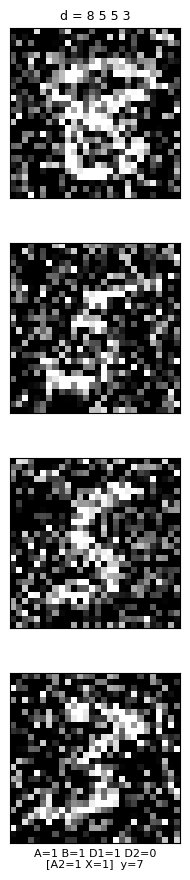

In [8]:
def show_sample(dataset, index, axes=None):
    """Plot every digit channel of one sample, titled with its digits and labels."""
    item = dataset[index]
    features = item["features"]                       # [num_covariates, 28, 28]
    concepts = item["concepts"].tolist()
    hidden = item["hidden_concepts"].tolist()
    digits = item["digit_labels"].tolist()
    short_names = [n.split("::")[0] for n in concept_names]
    short_oracle = [n.split("::")[0] for n in oracle_names]

    n_ch = features.shape[0]
    if axes is None:
        _, axes = plt.subplots(n_ch, 1, figsize=(2.0, 2.3 * n_ch))
    for channel, ax in enumerate(axes):
        ax.imshow(features[channel], cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
    axes[0].set_title("d = " + " ".join(str(d) for d in digits), fontsize=9)
    axes[-1].set_xlabel(
        " ".join(f"{n}={v:.0f}" for n, v in zip(short_names, concepts))
        + "\n[" + " ".join(f"{n}={v:.0f}" for n, v in zip(short_oracle, hidden))
        + f"]  y={int(item['labels'])}",
        fontsize=8,
    )
    return axes


show_sample(trainset, 0)
plt.tight_layout()
plt.show()

## A grid of samples

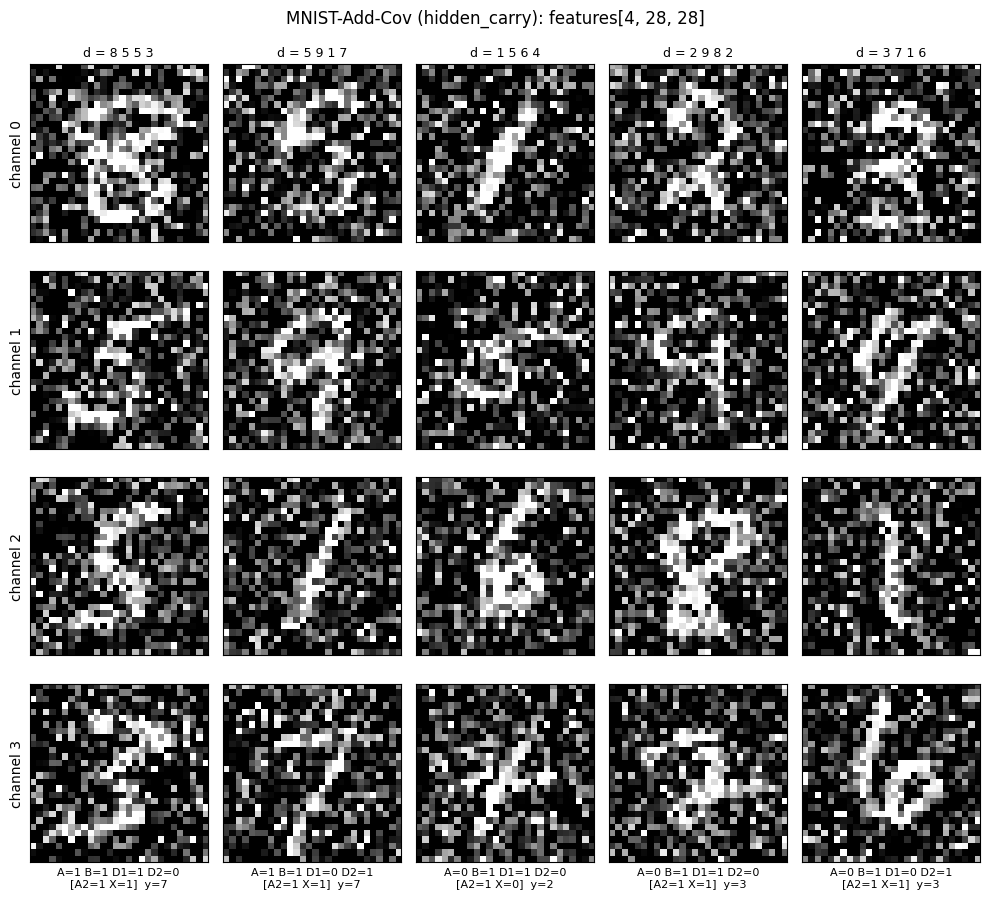

In [9]:
def show_samples(dataset, indices, suptitle=""):
    indices = list(indices)
    n_ch = dataset[indices[0]]["features"].shape[0]
    fig, axes = plt.subplots(n_ch, len(indices), figsize=(2.0 * len(indices), 2.3 * n_ch))
    for column, index in enumerate(indices):
        show_sample(dataset, index, axes=axes[:, column])
    for ch in range(n_ch):
        axes[ch, 0].set_ylabel(f"channel {ch}")
    fig.suptitle(
        suptitle or f"MNIST-Add-Cov ({config_data.experiment}): features[{n_ch}, 28, 28]"
    )
    fig.tight_layout()
    return fig


show_samples(trainset, range(5))
plt.show()

## Corrupted inputs

`corruption` is applied to digit 1 only, so this is the channel whose concepts
(`A1`, `H1`) get harder to read while digit 2 stays clean.

MNIST-Add-Cov split fingerprints (data seed=0, experiment=hidden_carry, planted_function=xor):
  train n=12000  sha256[:16]=07d39532c610848c
  val   n=2400   sha256[:16]=4f810f3a2dc12679
  test  n=10000  sha256[:16]=be3c30b27cac8be3
  concepts exposed: ['A::digit1_ge_5', 'B::digit2_ge_5', 'D1::digit3_ge_5', 'D2::digit4_ge_5']
  Matching fingerprints => identical train/val/test samples across machines (independent of which concepts are exposed).


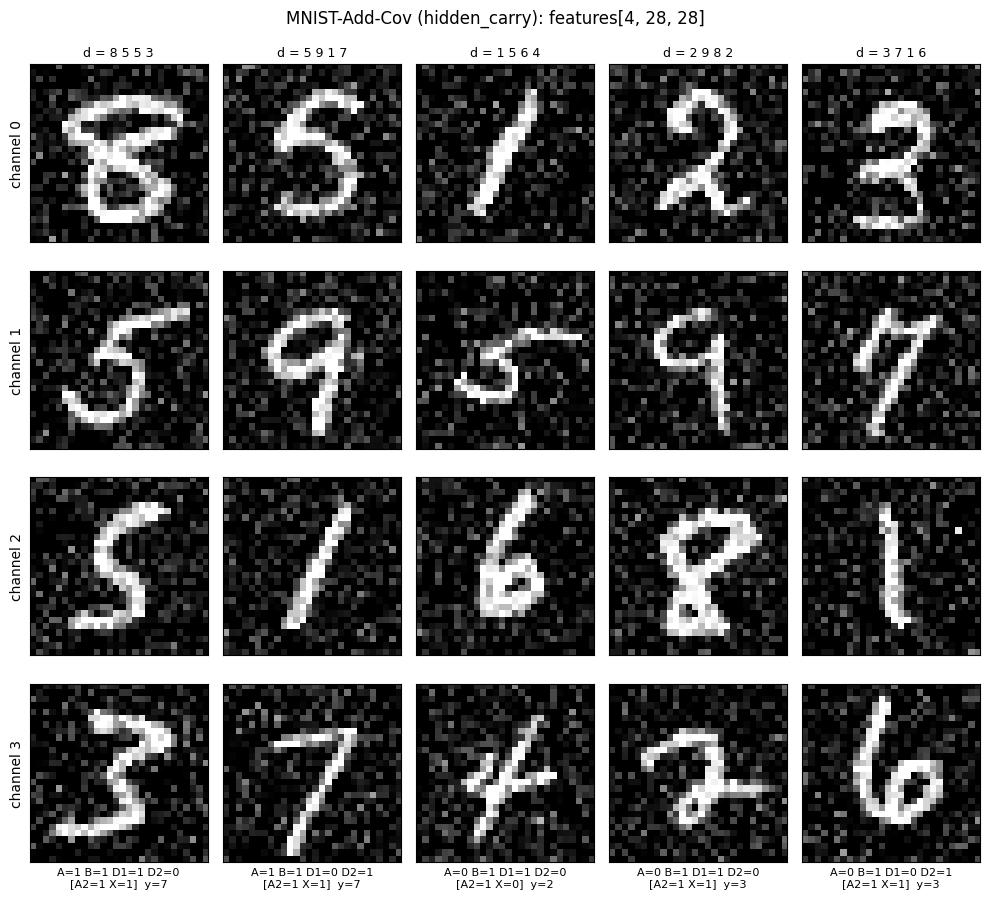

In [10]:
corrupted_config = OmegaConf.merge(
    config_data, {"corruption": "gaussian", "corruption_strength": 0.2}
)
corrupted_trainset, _, _ = get_MNIST_add_cov_datasets(corrupted_config, seed=0)

show_samples(corrupted_trainset, range(5))
plt.show()

## Analysis residual channel

### Task and concept performance


In [11]:
# Task and concept performance of the saved SCBM_RES run, recomputed from the dumps.
#
# The dumps hold y_true / y_pred / concept probabilities but no c_true, so the concept
# ground truth comes from the dataset objects above -- which assumes row i of the
# dataset is row i of the dump. The next cell verifies exactly that; the test-split
# numbers here reproducing the "Test:" line of log.txt is the second confirmation.
import ast
from pathlib import Path

import numpy as np
from sklearn.metrics import roc_auc_score

from utils.metrics import _roc_auc_score_with_missing  # support-weighted OVR, as in training

# RUN = Path(
#     "experiments/scbm_residual/MNIST-Add-Cov/"
#     "planted_xor_MNIST_ADD_no_prec_emp_perc_residuals_1_L_int_extension_loss_weight_1_2026-09-06_21-31-35_4e989"
# )

RUN = Path(
    "experiments/scbm_residual/MNIST-Add-Cov/"
    "planted_xor_MNIST_ADD_carry_clean_diagnostic_L_int_extension_loss_weight_1_2026-09-08_12-57-44_58d13"
)

# RUN = Path(
#     "experiments/scbm_residual/MNIST-Add-Cov/"
#     "planted_xor_MNIST_ADD_emp_perc_residuals_1_L_int_extension_loss_weight_1_2026-09-06_14-56-59_a7f7f"
# )

# RUN = Path(
#     "experiments/scbm_residual/MNIST-Add-Cov/"
#     "planted_xor_MNIST_ADD_non_lin_emp_perc_residuals_1_L_int_extension_loss_weight_1_2026-09-07_09-47-54_6a21a"
# )

# RUN = Path(
#     "experiments/scbm_residual/MNIST-Add-Cov/"
#     "planted_xor_MNIST_ADD_non_lin_no_prec_emp_perc_residuals_1_L_int_extension_loss_weight_1_2026-09-07_11-02-13_da59d")


SPLITS = (("train", trainset), ("val", valset), ("test", testset))


def split_performance(run, split, dataset):
    """Task and per-concept metrics for one split of one run."""
    y_true = torch.load(run / split / "y_true.pt").numpy()
    y_prob = torch.softmax(torch.load(run / split / "y_pred.pt"), dim=1).numpy()

    # Columns of the channel are [concepts | residuals]; only the concepts are supervised.
    # kept_concept_idx only exists on datasets built by the current module: a kernel that
    # imported it before `removed_concepts` was added holds instances without it, and there
    # every observed concept is exposed.
    kept = getattr(
        dataset, "kept_concept_idx", list(range(dataset.observed_concepts.shape[1]))
    )
    c_prob = torch.load(run / split / "concepts_residuals_pred_probs_mean.pt")
    c_prob = c_prob[:, : len(kept)].numpy()
    c_true = np.asarray(dataset.observed_concepts)[:, kept]

    return {
        "y_accuracy": (y_prob.argmax(1) == y_true).mean(),
        "y_AUROC": _roc_auc_score_with_missing(y_true, y_prob),
        "c_accuracy": ((c_prob > 0.5) == c_true).mean(),
        "c_AUROC": roc_auc_score(c_true, c_prob, average="macro"),
        "per_concept_accuracy": ((c_prob > 0.5) == c_true).mean(axis=0),
        "per_concept_AUROC": np.array(
            [roc_auc_score(c_true[:, j], c_prob[:, j]) for j in range(len(kept))]
        ),
    }


print(f"{RUN.name}\n")
print(f"{'split':<7}{'y_acc':>8}{'y_AUROC':>9}{'c_acc':>8}{'c_AUROC':>9}")
per_split = {}
for split, dataset in SPLITS:
    scores = split_performance(RUN, split, dataset)
    per_split[split] = scores
    print(f"{split:<7}{scores['y_accuracy']:>8.3f}{scores['y_AUROC']:>9.3f}"
          f"{scores['c_accuracy']:>8.3f}{scores['c_AUROC']:>9.3f}")

print(f"\nper concept (test){'':<4}{'acc':>8}{'AUROC':>9}")
for name, acc, auroc in zip(
    concept_names,
    per_split["test"]["per_concept_accuracy"],
    per_split["test"]["per_concept_AUROC"],
):
    print(f"  {name:<26}{acc:>8.3f}{auroc:>9.3f}")

# The run's own final test line, for comparison.
test_line = [ln for ln in RUN.joinpath("log.txt").read_text().splitlines()
             if ln.startswith("Test:")][-1]
print("\nlog.txt ->", test_line.strip())


/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/scbm_implementation/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


planted_xor_MNIST_ADD_carry_clean_diagnostic_L_int_extension_loss_weight_1_2026-09-08_12-57-44_58d13

split     y_acc  y_AUROC   c_acc  c_AUROC
train     0.799    0.967   0.999    1.000
val       0.688    0.915   0.911    0.965
test      0.676    0.916   0.907    0.966

per concept (test)         acc    AUROC
  A::digit1_ge_5               0.916    0.970
  B::digit2_ge_5               0.911    0.969
  D1::digit3_ge_5              0.901    0.963
  D2::digit4_ge_5              0.902    0.961

log.txt -> Test: target_loss: 1.280 concepts_loss: 3.645 l_int_extension_loss: 0.337 total_loss: 5.262 y_accuracy: 0.677 c_accuracy: 0.907 complete_c_accuracy: 0.677 target_jaccard: 0.511 concept_jaccard: 0.831 y_AUROC: 0.916 y_AUPR: 0.655 y_Brier: 0.461 y_ECE: 0.104 y_TL-ECE: 0.119 c_AUROC: 0.966 c_AUPR: 0.961 c_Brier: 0.082 c_ECE: 0.075 c_TL-ECE: 0.084


## Linear head

In [12]:
# Task head weights of the saved run, read straight out of the checkpoint.
#
# With head_arch='linear' the head is a single nn.Linear(C + R, pred_dim) whose input is
# the concept-residual vector in that order, so head.0.weight splits column-wise into a
# concept block and a residual block. In 'hard' concept_learning the head consumes the
# (near-binary) samples, in 'soft' it consumes the logits -- see
# SCBM_residual.compute_y_pred_logits.
def load_head_weights(run, checkpoint="model.pth", num_concepts=None):
    """Head weights of one run, split into concept and residual blocks."""
    state = torch.load(run / checkpoint, map_location="cpu")
    head = {k[len("head.") :]: v for k, v in state.items() if k.startswith("head.")}
    if "2.weight" in head:
        raise ValueError(f"{run.name} has head_arch='nonlinear'; no single linear weight")
    W, b = head["0.weight"], head["0.bias"]          # [pred_dim, C+R], [pred_dim]

    if num_concepts is None:  # first line of log.txt is the full training config
        num_concepts = ast.literal_eval(run.joinpath("log.txt").read_text().splitlines()[0])[
            "data"
        ]["num_concepts"]
    return {
        "W": W,
        "b": b,
        "W_concepts": W[:, :num_concepts],
        "W_residuals": W[:, num_concepts:],
        "num_concepts": num_concepts,
        "num_residuals": W.shape[1] - num_concepts,
    }


# h = load_head_weights(RUN)
# names = list(concept_names) + [f"res_{j}" for j in range(h["num_residuals"])]
# print(f"head: [{h['W'].shape[0]} classes, {h['num_concepts']} concepts + "
#       f"{h['num_residuals']} residuals]\n")

# # ||W[:, j]|| is how strongly input dimension j drives the class logits. The columns live
# # on different scales (concept samples in [0,1] vs unbounded residuals), so also scale
# # each column by that dimension's spread on the split the head actually saw.
# channel = torch.load(RUN / "test" / "concepts_residuals_sample_mean.pt")   # [N, C+R]
# scale = channel.std(dim=0)
# print(f"{'input':<26}{'|w|':>8}{'std':>8}{'|w|*std':>9}")
# for j, name in enumerate(names):
#     w = h["W"][:, j].norm()
#     print(f"  {name:<24}{w:>8.3f}{scale[j]:>8.3f}{w * scale[j]:>9.3f}")

# effect = h["W"].norm(dim=0) * scale
# res_share = effect[h["num_concepts"]:].pow(2).sum() / effect.pow(2).sum()
# print(f"\nresidual share of scaled squared head weight: {res_share:.3f}")

# # Small enough here to just look at the whole matrix (rows = classes = the sum y, with
# # that class's bias in the last column).
# short = [n.split("::")[0] for n in names]
# print("\n" + f"{'':<7}" + "".join(f"{n:>9}" for n in short) + f"{'bias':>9}")
# for k in range(h["W"].shape[0]):
#     print(f"y={k:<5}" + "".join(f"{v:>9.3f}" for v in h["W"][k].tolist())
#           + f"{h['b'][k]:>9.3f}")


### AUROC(r, M)

`M = H1 OR H2` is the middle bit of `y = 4*A1 + 2*M + X`. It is a deterministic
function of two *observed* concepts, so anything the residual knows about it is
leakage, not a hidden concept -- which is what the cleaned column tests.


In [13]:
c_res_mu = torch.load(RUN / "test" / "c_res_mu.pt")
print(f"c_res_mu.shape = {c_res_mu.shape}")

c_res_mu_prob = torch.load(RUN / "test" / "concepts_residuals_pred_probs_mean.pt")
print(f"c_res_mu_prob.shape = {c_res_mu_prob.shape}")

c_res_mu.shape = torch.Size([10000, 5])
c_res_mu_prob.shape = torch.Size([10000, 5])


In [14]:
# How well does the residual rank M (and the oracle variables), on its own?
#
# res_mu is the last column of c_res_mu.pt -- the mean of the Gaussian logit, i.e. the
# residual before sampling. Raw AUROC(res_mu, target) mixes in whatever observed-concept
# information leaked into the residual, so it is reported next to the cleaned version:
# r_clean = res_mu residualized on [1, c_mu] by OLS, the cleaning step of the pipeline.
# AUROC is direction-sensitive; a value below 0.5 means the residual ranks the target the
# other way round and |auc - 0.5| is still the strength.
def residual_target_aurocs(run, split, dataset):
    """Raw and c_mu-cleaned AUROC of res_mu against M, the concepts and the oracles."""
    channel = torch.load(run / split / "concepts_residuals_pred_probs_mean.pt").numpy()
    num_concepts = channel.shape[1] - 1          # this run has a single residual
    c_mu, res_mu = channel[:, :num_concepts], channel[:, num_concepts]

    observed = np.asarray(dataset.observed_concepts)
    hidden = np.asarray(dataset.hidden_concepts)
    targets = {
        "M = H1 or H2": np.logical_or(observed[:, 1] > 0.5, observed[:, 2] > 0.5),
        **{name.split("::")[0]: observed[:, j] > 0.5
           for j, name in enumerate(concept_names)},
        **{name.split("::")[0]: hidden[:, j] > 0.5
           for j, name in enumerate(oracle_names)},
    }

    design = np.concatenate([np.ones((len(c_mu), 1)), c_mu], axis=1)
    beta, *_ = np.linalg.lstsq(design, res_mu, rcond=None)
    r_clean = res_mu - design @ beta
    leaked_r2 = 1 - r_clean.var() / res_mu.var()

    return leaked_r2, {
        name: (roc_auc_score(t, res_mu), roc_auc_score(t, r_clean))
        for name, t in targets.items()
    }


for split, dataset in SPLITS:
    leaked_r2, aurocs = residual_target_aurocs(RUN, split, dataset)
    print(f"{split}  (R^2 of res_mu on c_mu: {leaked_r2:.3f})")
    print(f"  {'target':<14}{'AUROC(r)':>10}{'AUROC(r|c)':>12}")
    for name, (raw, cleaned) in aurocs.items():
        print(f"  {name:<14}{raw:>10.3f}{cleaned:>12.3f}")
    print()


train  (R^2 of res_mu on c_mu: 1.000)
  target          AUROC(r)  AUROC(r|c)
  M = H1 or H2       0.512       0.402
  A                  0.000       0.885
  B                  0.507       0.592
  D1                 0.505       0.264
  D2                 0.497       0.310
  A2                 0.506       0.512
  X                  0.257       0.746

val  (R^2 of res_mu on c_mu: 0.995)
  target          AUROC(r)  AUROC(r|c)
  M = H1 or H2       0.490       0.519
  A                  0.031       0.583
  B                  0.508       0.725
  D1                 0.494       0.303
  D2                 0.515       0.344
  A2                 0.505       0.551
  X                  0.268       0.662

test  (R^2 of res_mu on c_mu: 0.995)
  target          AUROC(r)  AUROC(r|c)
  M = H1 or H2       0.503       0.471
  A                  0.033       0.676
  B                  0.501       0.694
  D1                 0.514       0.261
  D2                 0.498       0.391
  A2                 0.503   

### Split alignment


In [15]:
# Does the split this notebook rebuilds match the one the SCBM_RES run trained on?
#
# The saved channel dumps carry y_true but no c_true, so the oracle labels
# (hidden_concepts, digit_labels, ...) have to come from the dataset object. That is
# only legitimate if row i of the dataset is row i of the dump, and y_true is the one
# saved tensor that can prove it: y = 4*A1 + 2*(H1 or H2) + X is a deterministic
# function of the sample, so identical y over the whole split means identical samples
# in identical order.

# First line of log.txt is the full run config: confirm the settings that determine
# the split agree with the ones this notebook loaded, before comparing the labels.
run_config = ast.literal_eval(RUN.joinpath("log.txt").read_text().splitlines()[0])
SPLIT_KEYS = (
    "train_dataset_size", "val_dataset_size", "test_dataset_size", "val_percent",
    "planted_function", "corruption", "corruption_strength", "corruption_probability",
    "test_corruption", "test_corruption_strength", "test_corruption_probability",
)
print(f"run seed = {run_config['seed']} (this notebook rebuilt with seed=0)")
for key in SPLIT_KEYS:
    theirs, ours = run_config["data"].get(key), config_data.get(key)
    flag = "" if theirs == ours else "   <-- DIFFERS"
    print(f"  {key:<28} run={theirs!s:<8} notebook={ours!s:<8}{flag}")

print()
for split, dataset in SPLITS:
    saved = torch.load(RUN / split / "y_true.pt").cpu().numpy().ravel()
    local = np.asarray(dataset.task_labels)
    identical = saved.shape == local.shape and bool((saved == local).all())
    print(f"{split:<6} saved n={saved.shape[0]:<6} dataset n={local.shape[0]:<6} identical={identical}")
    if not identical:
        n = min(len(saved), len(local))
        print(f"       agreement over first {n}: {(saved[:n] == local[:n]).mean():.4f}")


run seed = 0 (this notebook rebuilt with seed=0)
  train_dataset_size           run=12000    notebook=12000   
  val_dataset_size             run=2400     notebook=2400    
  test_dataset_size            run=10000    notebook=10000   
  val_percent                  run=0.2      notebook=0.2     
  planted_function             run=xor      notebook=xor     
  corruption                   run=gaussian notebook=gaussian
  corruption_strength          run=0        notebook=0.5        <-- DIFFERS
  corruption_probability       run=0        notebook=1.0        <-- DIFFERS
  test_corruption              run=gaussian notebook=gaussian
  test_corruption_strength     run=0        notebook=0.5        <-- DIFFERS
  test_corruption_probability  run=0        notebook=1.0        <-- DIFFERS

train  saved n=12000  dataset n=12000  identical=True
val    saved n=2400   dataset n=2400   identical=True
test   saved n=10000  dataset n=10000  identical=True


### Covariance analysis (MNIST_ADD.pdf §11–§14, §16)


In [16]:
# Covariance analysis -- MNIST_ADD.pdf sections 11-14 and 16.
#
# Section 11: covariance_matrices.pt already holds Sigma = L L^T. The validator does the
# reconstruction (`cov = triang_cov @ triang_cov.transpose(1,2)`) before saving, so the
# saved tensor is Sigma itself and must NOT be squared again.
#
# Written for arbitrary R so the same cell serves the R=5 identification run; with R=1 the
# argmax over residual dimensions is degenerate and only the sign structure is informative.
from scipy import stats
from scipy.special import expit

SPLIT = "test"
dataset = testset

Sigma = torch.load(RUN / SPLIT / "covariance_matrices.pt").numpy()        # [N, C+R, C+R]
mu = torch.load(RUN / SPLIT / "c_res_mu.pt").numpy()                      # [N, C+R]
c_prob = torch.load(RUN / SPLIT / "concepts_residuals_pred_probs_mean.pt").numpy()
n_concepts = len(getattr(dataset, "kept_concept_idx",
                         list(range(dataset.observed_concepts.shape[1]))))
n_residuals = Sigma.shape[1] - n_concepts
A1 = 0  # index of A1 in the concept block

a2 = np.asarray(dataset.hidden_concepts)[:, 0]
x_hidden = np.asarray(dataset.hidden_concepts)[:, 1]

# rho^{(n)}_{A1,r} = Sigma_{A1,r} / sqrt(Sigma_{A1,A1} Sigma_{r,r})   (section 12)
sd = np.sqrt(np.einsum("nii->ni", Sigma))
rho = Sigma / (sd[:, :, None] * sd[:, None, :])
rho_a1r = rho[:, A1, n_concepts:]                                        # [N, R]

# Uncertainty subsets (section 12): p_hat(A1) in (0.25, 0.75), or top-quartile variance.
subsets = {
    "all": np.ones(len(rho), bool),
    "U_p": (c_prob[:, A1] > 0.25) & (c_prob[:, A1] < 0.75),
    "U_var": Sigma[:, A1, A1] >= np.quantile(Sigma[:, A1, A1], 0.75),
}

print(f"{RUN.name}\nC={n_concepts}  R={n_residuals}  split={SPLIT}\n")
print("== is there any off-diagonal structure at all? ==")
off = ~np.eye(Sigma.shape[1], dtype=bool)
print(f"  mean |rho| over off-diagonal entries : {np.abs(rho).mean(0)[off].mean():.5f}"
      f"   (max pair {np.abs(rho).mean(0)[off].max():.5f})")
print(f"  mean diag(Sigma)                     : {Sigma.diagonal(axis1=1, axis2=2).mean(0).round(3)}")

print("\n== section 12: identification score S_r = E_U |rho(A1, r)| ==")
for name, U in subsets.items():
    if U.sum() < 10:
        print(f"  {name:<6} |U|={U.sum():<5} too small")
        continue
    S_r = np.abs(rho_a1r[U]).mean(0)
    print(f"  {name:<6} |U|={U.sum():<5} S_r={S_r.round(5)}   r* = r{S_r.argmax()}")

print("\n== section 13: oracle validation, AUROC per residual dimension ==")
for j in range(n_residuals):
    v = mu[:, n_concepts + j]
    auc_x, auc_a2 = roc_auc_score(x_hidden, v), roc_auc_score(a2, v)
    print(f"  r{j}: AUROC(r,X)={auc_x:.3f} inv={max(auc_x, 1-auc_x):.3f} | "
          f"AUROC(r,A2)={auc_a2:.3f} inv={max(auc_a2, 1-auc_a2):.3f} | "
          f"sigma(mu_r) vs X: {roc_auc_score(x_hidden, expit(v)):.3f}")

print("\n== section 14: XOR sign flip, predicted E[rho|A2=0] > 0 > E[rho|A2=1] ==")
for name, U in subsets.items():
    if U.sum() < 10:
        continue
    for j in range(n_residuals):
        lo, hi = rho_a1r[U & (a2 == 0), j], rho_a1r[U & (a2 == 1), j]
        holds = lo.mean() > 0 > hi.mean()
        p = stats.ttest_ind(lo, hi, equal_var=False).pvalue
        print(f"  {name:<6} r{j}: E[rho|A2=0]={lo.mean():+.5f}  E[rho|A2=1]={hi.mean():+.5f}  "
              f"diff={lo.mean()-hi.mean():+.5f}  p={p:.2g}  -> {'HOLDS' if holds else 'no'}")

print("\n== section 16: head covariance contribution 2 w_kA1 w_kr Sigma_A1r ==")
# Section 16 assumes the linear head: g_k(z) = w_k^T z + b_k. With head_arch != linear the
# head is Linear(C+R, 256) -> ReLU -> Linear(256, K), so head.0.weight is [256, C+R] and the
# per-class decomposition below is not defined.
W = torch.load(RUN / "model.pth", map_location="cpu")["head.0.weight"].numpy()
if W.shape[0] != config_data.num_classes:
    print(f"  skipped: head.0.weight is {W.shape}, not [K={config_data.num_classes}, C+R]"
          f" -- this run used a non-linear head, where section 16 does not apply.")
    W = None
var_k = None if W is None else np.einsum("kj,njl,kl->nk", W, Sigma, W)  # Var(g_k | x)
for j in range(n_residuals if W is not None else 0):
    contrib = 2 * W[:, A1] * W[:, n_concepts + j] * Sigma[:, A1, n_concepts + j][:, None]
    share = np.abs(contrib).mean(0) / var_k.mean(0)
    print(f"  r{j}: mean |contribution| = {np.abs(contrib).mean():.4f}   "
          f"as a share of Var(g_k): {share.min():.5f}-{share.max():.5f}")


planted_xor_MNIST_ADD_carry_clean_diagnostic_L_int_extension_loss_weight_1_2026-09-08_12-57-44_58d13
C=4  R=1  split=test

== is there any off-diagonal structure at all? ==
  mean |rho| over off-diagonal entries : 0.39734   (max pair 0.78233)
  mean diag(Sigma)                     : [1.529 2.167 1.662 1.606 4.125]

== section 12: identification score S_r = E_U |rho(A1, r)| ==
  all    |U|=10000 S_r=[0.7824]   r* = r0
  U_p    |U|=245   S_r=[0.7824]   r* = r0
  U_var  |U|=10000 S_r=[0.7824]   r* = r0

== section 13: oracle validation, AUROC per residual dimension ==
  r0: AUROC(r,X)=0.258 inv=0.742 | AUROC(r,A2)=0.502 inv=0.502 | sigma(mu_r) vs X: 0.265

== section 14: XOR sign flip, predicted E[rho|A2=0] > 0 > E[rho|A2=1] ==
  all    r0: E[rho|A2=0]=-0.78240  E[rho|A2=1]=-0.78240  diff=+0.00000  p=1  -> no
  U_p    r0: E[rho|A2=0]=-0.78240  E[rho|A2=1]=-0.78240  diff=+0.00000  p=1  -> no
  U_var  r0: E[rho|A2=0]=-0.78240  E[rho|A2=1]=-0.78240  diff=+0.00000  p=1  -> no

== section 16: 

/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/scbm_implementation/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


### Average |Sigma| per class

`y = 4*A1 + 2*M + X`, so each class fixes the three bits of the label; comparing the
mean covariance across classes shows which of them the predicted `Sigma(x)` responds to.


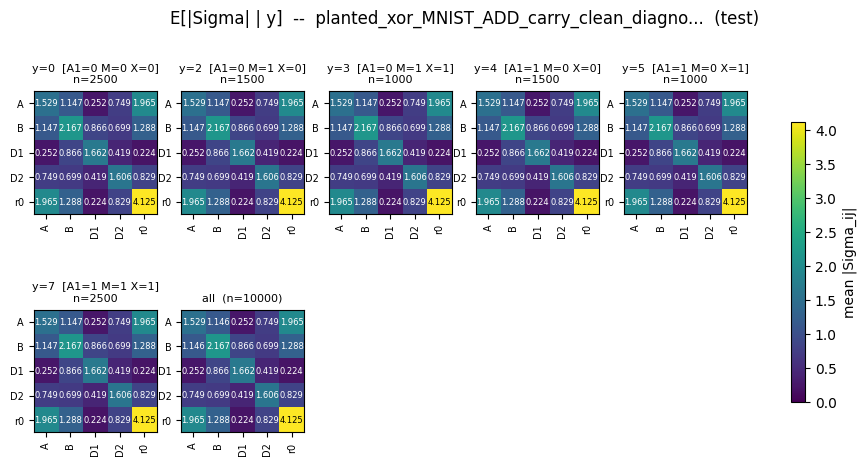

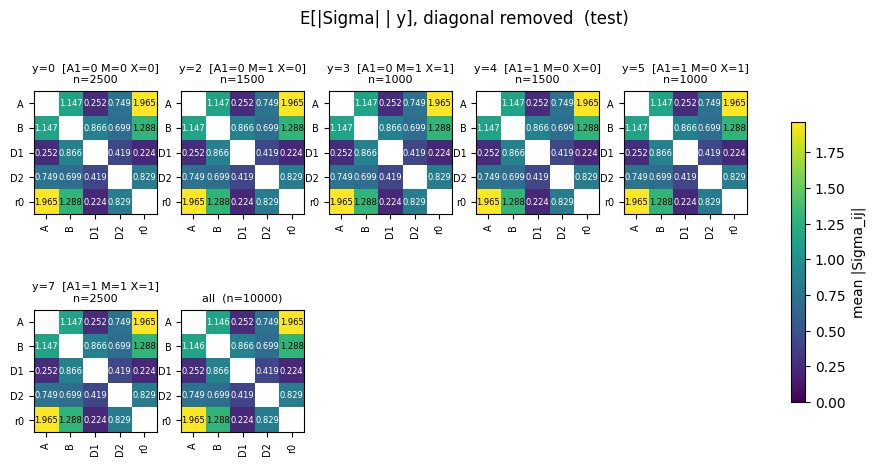

class       n     |S(A,r0)|     |S(B,r0)|    |S(D1,r0)|    |S(D2,r0)|
0        2500        1.9647        1.2881        0.2235        0.8286
2        1500        1.9647        1.2881        0.2235        0.8286
3        1000        1.9647        1.2881        0.2235        0.8286
4        1500        1.9647        1.2881        0.2235        0.8286
5        1000        1.9647        1.2881        0.2235        0.8286
7        2500        1.9647        1.2881        0.2235        0.8286
all     10000        1.9648        1.2881        0.2235        0.8286


In [17]:
# Average absolute covariance matrix, split by task class.
#
# Reuses Sigma / mu / dataset / n_concepts from the covariance cell above (SPLIT above
# selects the split). Each panel is E[|Sigma_ij(x)| | y = k] over the samples of class k.
# The diagonal (per-dimension variances) is much larger than the off-diagonal terms, so
# the same means are drawn twice: once on a shared full scale, once with the diagonal
# blanked and the colour scale set by the off-diagonal entries alone.
y_true = torch.load(RUN / SPLIT / "y_true.pt").numpy()
assert len(y_true) == len(Sigma), f"{len(y_true)} labels vs {len(Sigma)} covariances"

axis_names = [name.split("::")[0] for name in concept_names] + [
    f"r{j}" for j in range(n_residuals)
]
abs_cov = np.abs(Sigma)
present = [k for k in range(config_data.num_classes) if (y_true == k).any()]
per_class = {k: abs_cov[y_true == k].mean(0) for k in present}
per_class["all"] = abs_cov.mean(0)


def class_title(k):
    """y = 4*A1 + 2*M + X -- spell the bits out in the panel title."""
    if k == "all":
        return f"all  (n={len(y_true)})"
    return (f"y={k}  [A1={k >> 2} M={(k >> 1) & 1} X={k & 1}]\n"
            f"n={(y_true == k).sum()}")


def plot_class_covariances(mats, mask_diagonal, suptitle):
    """Grid of per-class mean |Sigma| heatmaps on one shared colour scale."""
    keys = list(mats)
    shown = {}
    for k in keys:
        m = mats[k].copy()
        if mask_diagonal:
            np.fill_diagonal(m, np.nan)
        shown[k] = m
    vmax = np.nanmax(np.stack(list(shown.values())))

    ncols = 3 if len(keys) <= 3 else min(len(keys), 5)
    nrows = int(np.ceil(len(keys) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(2.3 * ncols, 2.6 * nrows), squeeze=False
    )
    for ax, k in zip(axes.ravel(), keys):
        im = ax.imshow(shown[k], cmap="viridis", vmin=0, vmax=vmax)
        ax.set_title(class_title(k), fontsize=8)
        ax.set_xticks(range(len(axis_names)), axis_names, fontsize=7, rotation=90)
        ax.set_yticks(range(len(axis_names)), axis_names, fontsize=7)
        for i in range(len(axis_names)):
            for j in range(len(axis_names)):
                v = shown[k][i, j]
                if np.isnan(v):
                    continue
                ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=6,
                        color="white" if v < 0.6 * vmax else "black")
    for ax in axes.ravel()[len(keys):]:
        ax.axis("off")
    fig.colorbar(im, ax=axes, shrink=0.7, label="mean |Sigma_ij|")
    fig.suptitle(suptitle)
    return fig


plot_class_covariances(
    per_class, False, f"E[|Sigma| | y]  --  {RUN.name[:40]}...  ({SPLIT})"
)
plt.show()

plot_class_covariances(
    per_class, True, f"E[|Sigma| | y], diagonal removed  ({SPLIT})"
)
plt.show()

# The concept-residual block on its own: how much |Sigma_(c, r)| moves across classes.
print(f"{'class':<7}{'n':>6}" + "".join(
    f"{f'|S({c},{r})|':>14}"
    for c in axis_names[:n_concepts] for r in axis_names[n_concepts:]
))
for k, m in per_class.items():
    n = len(y_true) if k == "all" else (y_true == k).sum()
    row = "".join(f"{m[i, n_concepts + j]:>14.4f}"
                  for i in range(n_concepts) for j in range(n_residuals))
    print(f"{str(k):<7}{n:>6}{row}")


### Empirical covariance of the `c_res_mu` vectors

The panels above are the *predicted* per-sample `Sigma(x)` -- the conditional covariance
of the logits given one image. This cell is the other half of the law of total covariance:
`Cov(mu(x))` across samples, i.e. how the predicted means co-vary over the split, pooled
and within class.


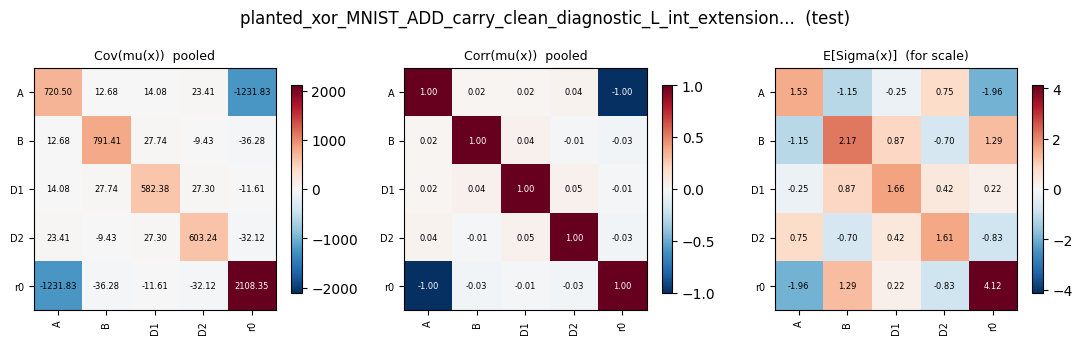

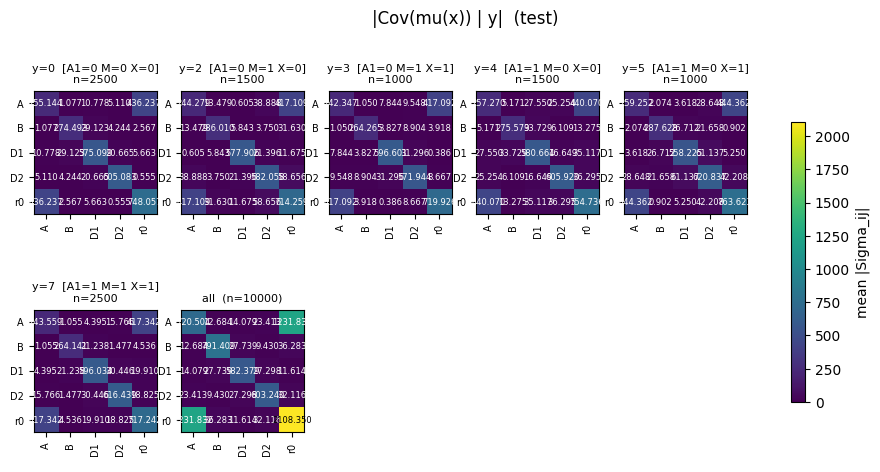

corr(mu) residual rows -- pooled and within class (test)

class       n      corr(A,r0)      corr(B,r0)     corr(D1,r0)     corr(D2,r0)
0        2500          -0.999          -0.006          -0.009          -0.001
2        1500          -0.999          -0.070           0.018          -0.091
3        1000          -0.999          -0.009           0.001          -0.014
4        1500          -0.999          -0.029          -0.053          -0.054
5        1000          -0.999          -0.002           0.008          -0.061
7        2500          -0.999          -0.010           0.030          -0.028
all     10000          -0.999          -0.028          -0.010          -0.028


In [18]:
# Empirical covariance of the predicted means, Cov(mu(x)), pooled and per class.
#
# Law of total covariance for the concept-residual logits:
#     Cov(eta) = Cov(mu(x))  +  E[Sigma(x)]
# The first term is what this cell plots -- variation of the predicted mean across
# images, which is where the concept/residual *signal* lives -- and the second is the
# per-sample Sigma averaged, plotted alongside for scale. The two answer different
# questions: E[Sigma] says how uncertain one prediction is, Cov(mu) says how the
# predictions move together across the dataset.
#
# mu / Sigma / y_true / axis_names / per_class come from the two cells above.
mu_cov = np.cov(mu, rowvar=False)
mu_corr = np.corrcoef(mu, rowvar=False)
mean_Sigma = Sigma.mean(0)


def plot_matrix(m, ax, title, symmetric, cmap):
    """One annotated heatmap; `symmetric` centres a diverging scale on zero."""
    v = np.nanmax(np.abs(m))
    im = ax.imshow(m, cmap=cmap, vmin=-v if symmetric else 0, vmax=v)
    ax.set_title(title, fontsize=9)
    ax.set_xticks(range(len(axis_names)), axis_names, fontsize=7, rotation=90)
    ax.set_yticks(range(len(axis_names)), axis_names, fontsize=7)
    for i in range(len(axis_names)):
        for j in range(len(axis_names)):
            if np.isnan(m[i, j]):
                continue
            # Diverging maps are light near zero and dark at both ends; viridis is
            # the other way round, so the text colour rule flips with `symmetric`.
            shade = abs(m[i, j]) / v
            dark_cell = shade > 0.6 if symmetric else shade < 0.6
            ax.text(j, i, f"{m[i, j]:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if dark_cell else "black")
    plt.colorbar(im, ax=ax, shrink=0.75)
    return im


fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
plot_matrix(mu_cov, axes[0], "Cov(mu(x))  pooled", True, "RdBu_r")
plot_matrix(mu_corr, axes[1], "Corr(mu(x))  pooled", True, "RdBu_r")
plot_matrix(mean_Sigma, axes[2], "E[Sigma(x)]  (for scale)", True, "RdBu_r")
fig.suptitle(f"{RUN.name[:60]}...  ({SPLIT})")
fig.tight_layout()
plt.show()

# Within-class Cov(mu): the pooled version is dominated by between-class movement of the
# mean (the concepts are what the class is made of), so conditioning on y is what shows
# the structure left over inside a class.
within = {k: (np.cov(mu[y_true == k], rowvar=False) if k != "all"
              else np.cov(mu, rowvar=False)) for k in per_class}
plot_class_covariances({k: np.abs(v) for k, v in within.items()}, False,
                       f"|Cov(mu(x)) | y|  ({SPLIT})")
plt.show()

# The residual's row, as correlations: pooled, then within each class.
print(f"corr(mu) residual rows -- pooled and within class ({SPLIT})\n")
print(f"{'class':<7}{'n':>6}" + "".join(
    f"{f'corr({c},{r})':>16}"
    for r in axis_names[n_concepts:] for c in axis_names[:n_concepts]))
for k in per_class:
    sub = mu if k == "all" else mu[y_true == k]
    n = len(sub)
    corr = np.corrcoef(sub, rowvar=False)
    row = "".join(f"{corr[i, n_concepts + j]:>16.3f}"
                  for j in range(n_residuals) for i in range(n_concepts))
    print(f"{str(k):<7}{n:>6}{row}")
